# Analysis of a Classification Model

### Initialization

Importing the modules.

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Subset
from tqdm import tqdm
import tabulate
import copy

Mounting the drive.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Checking if the data has been loaded correctly.

In [ ]:
!ls /content/drive/MyDrive/Data

id_ood_samples.zip  test.zip  train.zip


Moving the data from the drive to colab's local storage and unzipping it to the appropriate folder.

In [ ]:
# Copying and pasting the ZIP files
!cp /content/drive/MyDrive/Data/train.zip /content/
!cp /content/drive/MyDrive/Data/test.zip /content/
!cp /content/drive/MyDrive/Data/id_ood_samples.zip /content/

# Unzipping into a appropriate folder
!unzip -q /content/train.zip -d /content/Data/
!unzip -q /content/test.zip -d /content/Data/
!unzip -q /content/id_ood_samples.zip -d /content/Data/id_ood_samples/

### Pre-processing

Reading the data using `ImageFolder`.

In [ ]:
train_dir = '/content/Data/train'
test_dir = '/content/Data/test'
dataset = datasets.ImageFolder(train_dir, transform=None)

Splitting the training data into training and valiation data with a ratio of 90:10 in a stratified manner using `StratifiedShuffleSplit`.

In [ ]:
# Selecting the indices for the split
labels = np.array(dataset.targets)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=27)
train_idx, val_idx = next(splitter.split(np.zeros(len(labels)), labels))

# Making the subsets
train_subset = Subset(dataset, train_idx)
val_subset = Subset(dataset, val_idx)

# Verifying the splits
print("Training set size: ", len(train_subset))
print("Validation set set size: ", len(val_subset))

# Verifying the type / shape of the feature-label pair
print("Feature shape: ", type(train_subset[0][0]))
print("Label shape: ", type(train_subset[0][1]))

Training set size:  28800
Validation set set size:  3200
Feature shape:  <class 'PIL.Image.Image'>
Label shape:  <class 'int'>


Creating a function to claculate the mean and standard deviation per channel and then calculating it for the train subset.

In [ ]:
def compute_mean_std_from_subset(subset):
    mean = 0
    std = 0

    idx_iter = tqdm(range(len(subset)), desc='idx', leave=False)
    for idx in idx_iter:
        img, _ = subset[idx]
        # Dividing by 255 to scale pixel values to [0, 1] to match ToTensor(),
        # as we'll later apply normalization on the tensor.
        img = np.asarray(img).astype(np.float32) / 255
        mean += img.mean(axis=(0, 1))
        std += img.std(axis=(0, 1))
    mean /= len(subset)
    std /= len(subset)
    return mean, std

train_mean, train_std = compute_mean_std_from_subset(train_subset)
print("\nMean:", train_mean, "Std:", train_std)


Mean: [0.5516779  0.48268026 0.73340744] Std: [0.191177   0.23847724 0.10479854]


In [ ]:
train_mean = np.array([0.5516779,  0.48268026, 0.73340744])
train_std = np.array([0.191177,   0.23847724, 0.10479854])

Reloading the datasets with normalization applied.

In [ ]:
# Converting to tensor and normalizing using the train mean and std
non_train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

# Relaoding the datasets
full_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
non_aug_full_dataset = datasets.ImageFolder(train_dir, transform=non_train_transforms)
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(non_aug_full_dataset, val_idx)
non_aug_train_dataset = Subset(non_aug_full_dataset, train_idx)
test_dataset = datasets.ImageFolder(test_dir, transform=non_train_transforms)

Creating the data loaders.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
non_aug_train_loader = DataLoader(non_aug_train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader_failure_test = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=0)

### Base model

Creating the base model structure.

In [ ]:
class Base_Model(nn.Module):
    def __init__(self):
        super(Base_Model, self).__init__()
        # Convolutional head
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 3x3
        )
        # Linear head
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 8)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Creating a function to view the training and validation loss and accuracy values over the epochs.

In [ ]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    # Defining a list of epochs
    epochs = range(1, len(train_loss) + 1)
    # Creating a figure with 2 subplots
    _, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Creating the first subplot for loss
    axes[0].plot(epochs, train_loss, label='Train Loss', marker='o')
    axes[0].plot(epochs, val_loss, label='Validation Loss', marker='o')
    axes[0].set_title('Loss vs Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    # Creating the second subplot for accuracy
    axes[1].plot(epochs, train_acc, label='Train Accuracy', marker='o')
    axes[1].plot(epochs, val_acc, label='Validation Accuracy', marker='o')
    axes[1].set_title('Accuracy vs Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)
    # Displaying the plots
    plt.tight_layout()
    plt.show()

Creating a function to train a model and provide training and validation loss and accuracy.

In [ ]:
# Defining the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15):

    # Initializing the best model and its accuracy
    best_val_accuracy = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    # Initializing the lists to store the training and validation loss and accuracy
    train_loss_list = []
    val_loss_list = []
    train_accuracy_list = []
    val_accuracy_list = []

    for epoch in range(epochs):

        # Initializing the training for an epoch
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        # Initializing the training progress bar for each epoch
        train_bar = tqdm(train_loader, desc='Training', leave=False)
        # Loading a batch
        for features, labels in train_bar:
            # Moving the features and labels of one batch on the same device
            features, labels = features.to(device), labels.to(device)
            # Forward and back propogation
            optimizer.zero_grad()
            predictions = model(features)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            # Calculating and summing up the training metrics for that batch
            train_loss += loss.item() * features.size(0)
            _, predicted_class = torch.max(predictions, 1)
            total += labels.size(0)
            correct += (predicted_class == labels).sum().item()
        # Averaging to get the training loss and accuracy
        avg_train_loss = train_loss / total
        train_accuracy = 100 * correct / total

        # Initializing the validation for an epoch
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        # Initializing the validation progress bar for each epoch
        val_bar = tqdm(val_loader, desc='Validating', leave=False)
        with torch.no_grad():
            # Loading a batch
            for features, labels in val_bar:
                # Moving the features and labels of one batch on the same device
                features, labels = features.to(device), labels.to(device)
                # Generate the model predictions
                predictions = model(features)
                loss = criterion(predictions, labels)
                # Calculating and summing up the validation metrics for that batch
                val_loss += loss.item() * features.size(0)
                _, predicted_class = torch.max(predictions, 1)
                total += labels.size(0)
                correct += (predicted_class == labels).sum().item()
        # Averaging to get the validation loss and accuracy
        avg_val_loss = val_loss / total
        val_accuracy = 100 * correct / total

        # Updating the model weights if the val accuracy is higher than teh current best val accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())

        # Appending the training and validation metrics to the lists
        train_loss_list.append(avg_train_loss)
        val_loss_list.append(avg_val_loss)
        train_accuracy_list.append(train_accuracy)
        val_accuracy_list.append(val_accuracy)

        # Printing the loss and accuracy for every epoch
        print(f"Epoch [{epoch+1}/{epochs}]  "
              f"Train Loss: {avg_train_loss:.4f}  Acc: {train_accuracy:.2f}%  "
              f"Val Loss: {avg_val_loss:.4f}  Acc: {val_accuracy:.2f}%")

    # Plotting the training curves
    plot_training_curves(train_loss_list, val_loss_list, train_accuracy_list, val_accuracy_list)

    # Loading the best weights
    model.load_state_dict(best_model_wts)

Compiling and training the base model.

Epoch [1/15]  Train Loss: 1.5040  Acc: 42.39%  Val Loss: 1.1708  Acc: 57.56%


Epoch [2/15]  Train Loss: 1.0658  Acc: 60.48%  Val Loss: 0.9972  Acc: 62.97%


Epoch [3/15]  Train Loss: 0.8735  Acc: 68.19%  Val Loss: 0.8402  Acc: 70.50%


Epoch [4/15]  Train Loss: 0.7411  Acc: 73.26%  Val Loss: 0.7685  Acc: 72.72%


Epoch [5/15]  Train Loss: 0.6547  Acc: 76.35%  Val Loss: 0.7275  Acc: 74.53%


...

Epoch [11/15]  Train Loss: 0.2382  Acc: 91.50%  Val Loss: 0.9680  Acc: 73.53%


Epoch [12/15]  Train Loss: 0.1933  Acc: 93.28%  Val Loss: 1.0780  Acc: 72.72%


Epoch [13/15]  Train Loss: 0.1381  Acc: 95.19%  Val Loss: 1.1553  Acc: 73.84%


Epoch [14/15]  Train Loss: 0.1471  Acc: 94.78%  Val Loss: 1.2263  Acc: 73.88%


Epoch [15/15]  Train Loss: 0.1085  Acc: 96.22%  Val Loss: 1.3348  Acc: 72.94%


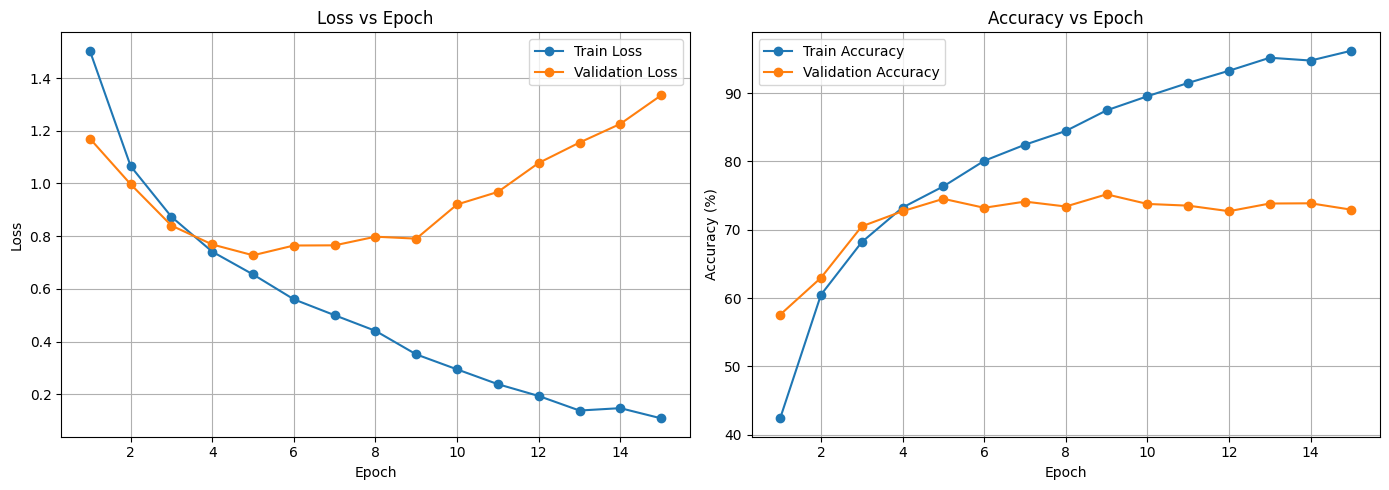

In [ ]:
# Initializing the model and moving it on the same device
base_model = Base_Model().to(device)
# Defining the loss function - cross entropy loss
criterion = nn.CrossEntropyLoss()
# Defining the optimizer - Adam with a learning rate of 0.001
optimizer = optim.Adam(base_model.parameters(), lr=0.001)

# Training the model
train_model(base_model, non_aug_train_loader, val_loader, criterion, optimizer, epochs=15)

Saving the model.

In [ ]:
torch.save(base_model.state_dict(), "base_model.pth")

Loading the model.

In [ ]:
base_model.load_state_dict(torch.load("base_model.pth", map_location=device))

<All keys matched successfully>

Creating a function to calculate the accuracy, sensitivity, specificity, precision, NPV and F-1 score for every class and also the average.

In [ ]:
def compute_classification_metrics(cm, class_names):
    num_classes = cm.shape[0]
    metrics = []

    for i in range(num_classes):
        # Computing TP, FP, FN, TN
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        # Computing metrics and handling division by zero
        accuracy = (TP + TN) / cm.sum() if cm.sum() != 0 else 0
        sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        npv = TN / (TN + FN) if (TN + FN) != 0 else 0
        f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) != 0 else 0

        # Appending the metrics for the current class
        metrics.append({
            "Class": class_names[i],
            "Accuracy": accuracy,
            "Sensitivity (Recall)": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "NPV": npv,
            "F1 Score": f1
        })

    avg_accuracy = cm.diagonal().sum() / cm.sum() if cm.sum() != 0 else 0

    return [metrics, avg_accuracy]

Creating a function to test a model and view the confusion matrix and the corresponding evaluation scores.

In [ ]:
def evaluate_model(model, test_dataloader, class_names, device):

    # Initializing the testing process
    model.eval()
    all_preds = []
    all_labels = []

    # Generating the predictions
    with torch.no_grad():
      # Initializing the testing progress bar
        test_bar = tqdm(test_dataloader, desc='Testing', leave=False)
        for images, labels in test_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculating and printing the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    # Calculating the classification metrics
    metrics, average_accuracy = compute_classification_metrics(cm, class_names)
    metrics_df = pd.DataFrame(metrics)
    print(tabulate.tabulate(metrics_df, headers='keys', tablefmt='fancy_grid', showindex=False))
    print(f"Average Accuracy: {average_accuracy}")

Testing the base model.

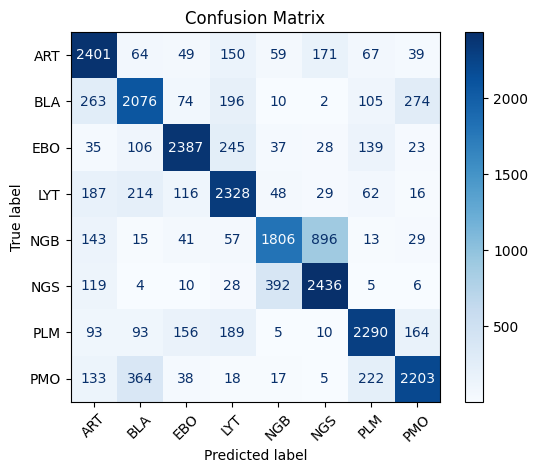

╒═════════╤════════════╤════════════════════════╤═══════════════╤═════════════╤══════════╤════════════╕
│ Class   │   Accuracy │   Sensitivity (Recall) │   Specificity │   Precision │      NPV │   F1 Score │
╞═════════╪════════════╪════════════════════════╪═══════════════╪═════════════╪══════════╪════════════╡
│ ART     │   0.9345   │               0.800333 │      0.953667 │    0.711618 │ 0.970959 │   0.753373 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ BLA     │   0.925667 │               0.692    │      0.959048 │    0.707084 │ 0.956134 │   0.699461 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ EBO     │   0.954292 │               0.795667 │      0.976952 │    0.831418 │ 0.970988 │   0.813149 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ LYT     │   0.935208 │               0.776    │      0.957952 

In [ ]:
class_names = dataset.classes
evaluate_model(base_model, test_loader, class_names, device)

### Improved model

Creating the improved model structure.

In [ ]:
class Improved_Model(nn.Module):
    def __init__(self):
        super(Improved_Model, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 8)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Compiling and training the improved model.

Epoch [1/15]  Train Loss: 1.4342  Acc: 54.23%  Val Loss: 1.1322  Acc: 69.88%


Epoch [2/15]  Train Loss: 1.1710  Acc: 69.48%  Val Loss: 1.0901  Acc: 73.00%


Epoch [3/15]  Train Loss: 1.0905  Acc: 73.92%  Val Loss: 1.0334  Acc: 74.84%


Epoch [4/15]  Train Loss: 1.0358  Acc: 76.61%  Val Loss: 0.9571  Acc: 78.44%


Epoch [5/15]  Train Loss: 1.0026  Acc: 78.22%  Val Loss: 0.9329  Acc: 79.41%


...

Epoch [11/15]  Train Loss: 0.8876  Acc: 83.81%  Val Loss: 0.8695  Acc: 82.50%


Epoch [12/15]  Train Loss: 0.8724  Acc: 84.31%  Val Loss: 0.8589  Acc: 82.47%


Epoch [13/15]  Train Loss: 0.8660  Acc: 84.35%  Val Loss: 0.8595  Acc: 82.69%


Epoch [14/15]  Train Loss: 0.8480  Acc: 85.56%  Val Loss: 0.8594  Acc: 82.97%


Epoch [15/15]  Train Loss: 0.8403  Acc: 85.80%  Val Loss: 0.8566  Acc: 83.59%


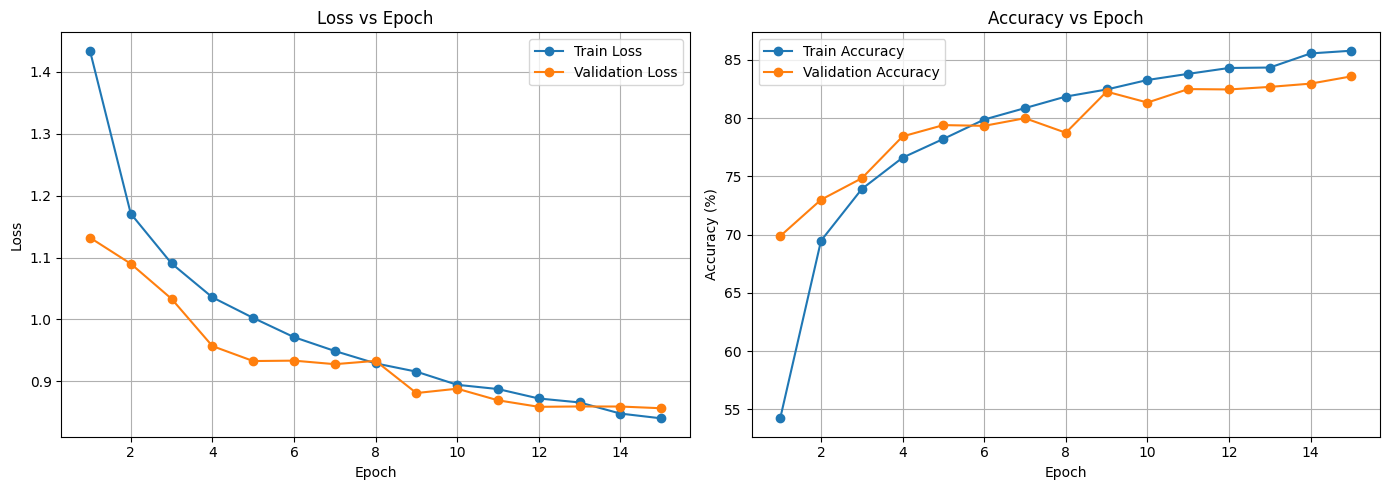

In [ ]:
# Initializing the model and moving it on the same device
improved_model = Improved_Model().to(device)
# Defining the loss function - cross entropy loss
criterion = nn.CrossEntropyLoss()
# Defining the optimizer - Adam with a learning rate of 0.001
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

# Training the model
train_model(improved_model, train_loader, val_loader, criterion, optimizer, epochs=15)

Savinig the model.

In [ ]:
torch.save(improved_model.state_dict(), "improved_model.pth")

Loading the model.

In [ ]:
improved_model.load_state_dict(torch.load("improved_model.pth", map_location=device))

<All keys matched successfully>

Testing the improved model.

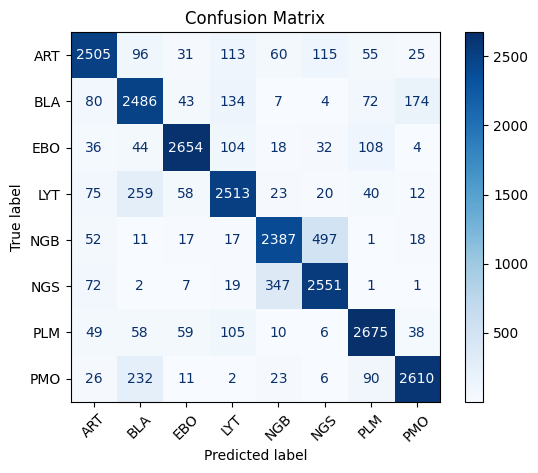

╒═════════╤════════════╤════════════════════════╤═══════════════╤═════════════╤══════════╤════════════╕
│ Class   │   Accuracy │   Sensitivity (Recall) │   Specificity │   Precision │      NPV │   F1 Score │
╞═════════╪════════════╪════════════════════════╪═══════════════╪═════════════╪══════════╪════════════╡
│ ART     │   0.963125 │               0.835    │      0.981429 │    0.865285 │ 0.976546 │   0.849873 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ BLA     │   0.949333 │               0.828667 │      0.966571 │    0.779799 │ 0.975303 │   0.803491 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ EBO     │   0.976167 │               0.884667 │      0.989238 │    0.921528 │ 0.983617 │   0.902721 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ LYT     │   0.959125 │               0.837667 │      0.976476 

In [ ]:
evaluate_model(improved_model, test_loader, class_names, device)

### Ablation study - 1 (no augmentation)

Creating the model - 1 structure.

In [ ]:
class Model_1(nn.Module):
    def __init__(self):
        super(Model_1, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 8)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Compiling and training the model 1.

Epoch [1/15]  Train Loss: 1.4841  Acc: 51.40%  Val Loss: 1.3217  Acc: 58.28%


Epoch [2/15]  Train Loss: 1.2029  Acc: 67.02%  Val Loss: 1.1012  Acc: 72.25%


Epoch [3/15]  Train Loss: 1.1086  Acc: 72.39%  Val Loss: 1.0281  Acc: 75.72%


Epoch [4/15]  Train Loss: 1.0300  Acc: 76.60%  Val Loss: 1.0615  Acc: 73.66%


Epoch [5/15]  Train Loss: 0.9804  Acc: 79.02%  Val Loss: 1.0405  Acc: 74.53%


...

Epoch [11/15]  Train Loss: 0.7712  Acc: 89.75%  Val Loss: 0.9412  Acc: 79.53%


Epoch [12/15]  Train Loss: 0.7419  Acc: 91.08%  Val Loss: 0.9678  Acc: 79.19%


Epoch [13/15]  Train Loss: 0.7220  Acc: 92.40%  Val Loss: 0.9680  Acc: 79.41%


Epoch [14/15]  Train Loss: 0.7000  Acc: 93.67%  Val Loss: 1.0688  Acc: 76.84%


Epoch [15/15]  Train Loss: 0.6849  Acc: 94.22%  Val Loss: 0.9691  Acc: 80.22%


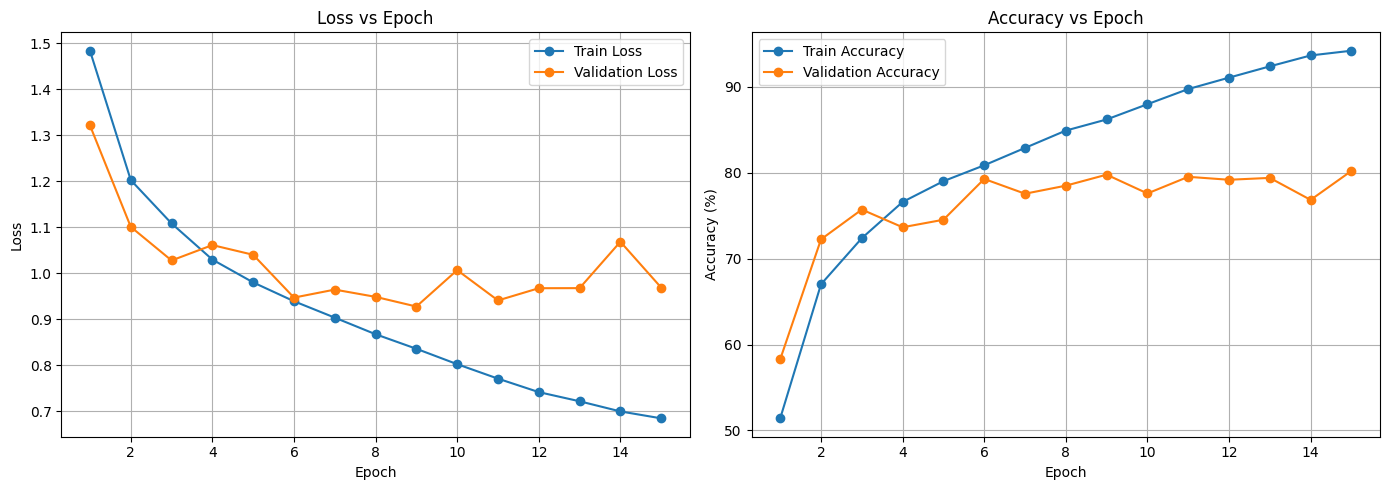

In [ ]:
# Initializing the model and moving it on the same device
model_1 = Model_1().to(device)
# Defining the loss function - cross entropy loss
criterion = nn.CrossEntropyLoss()
# Defining the optimizer - Adam with a learning rate of 0.001
optimizer = optim.Adam(model_1.parameters(), lr=0.001)

# Training the model
train_model(model_1, non_aug_train_loader, val_loader, criterion, optimizer, epochs=15)

Saving the model.

In [ ]:
torch.save(model_1.state_dict(), "model_1.pth")

Loading the model.

In [ ]:
model_1.load_state_dict(torch.load("model_1.pth", map_location=device))

C:\Users\naman\AppData\Local\Temp\ipykernel_13720\1863884282.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load("model_1.pth", map_locati

<All keys matched successfully>

Testing the model 1.

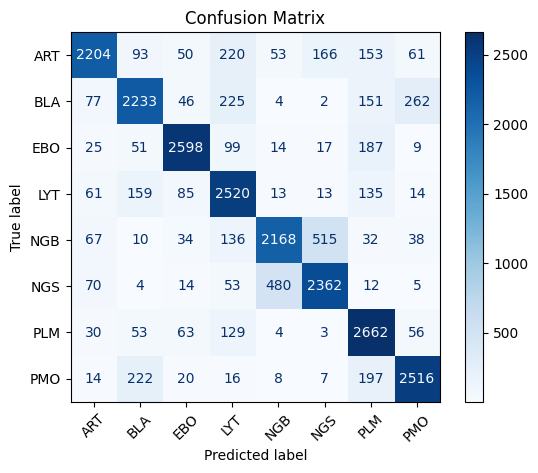

╒═════════╤════════════╤════════════════════════╤═══════════════╤═════════════╤══════════╤════════════╕
│ Class   │   Accuracy │   Sensitivity (Recall) │   Specificity │   Precision │      NPV │   F1 Score │
╞═════════╪════════════╪════════════════════════╪═══════════════╪═════════════╪══════════╪════════════╡
│ ART     │   0.9525   │               0.734667 │      0.983619 │    0.864992 │ 0.962894 │   0.794521 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ BLA     │   0.943375 │               0.744333 │      0.97181  │    0.790442 │ 0.963778 │   0.766695 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ EBO     │   0.97025  │               0.866    │      0.985143 │    0.892784 │ 0.980939 │   0.879188 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ LYT     │   0.943417 │               0.84     │      0.95819  

In [ ]:
evaluate_model(model_1, test_loader, class_names, device)

### Ablation study 2 (no batch norm)

Creating model 2 structure.

In [ ]:
class Model_2(nn.Module):
    def __init__(self):
        super(Model_2, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 8)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Compiling and training the model 2.

Epoch [1/15]  Train Loss: 1.5309  Acc: 47.88%  Val Loss: 1.2036  Acc: 66.62%


Epoch [2/15]  Train Loss: 1.2047  Acc: 66.77%  Val Loss: 1.0822  Acc: 71.59%


Epoch [3/15]  Train Loss: 1.0927  Acc: 72.56%  Val Loss: 1.0125  Acc: 75.47%


Epoch [4/15]  Train Loss: 1.0345  Acc: 75.53%  Val Loss: 0.9708  Acc: 78.03%


Epoch [5/15]  Train Loss: 0.9885  Acc: 77.67%  Val Loss: 0.9387  Acc: 79.22%


...

Epoch [11/15]  Train Loss: 0.8826  Acc: 82.99%  Val Loss: 0.8921  Acc: 81.59%


Epoch [12/15]  Train Loss: 0.8693  Acc: 83.77%  Val Loss: 0.8934  Acc: 82.16%


Epoch [13/15]  Train Loss: 0.8648  Acc: 83.89%  Val Loss: 0.8845  Acc: 82.28%


Epoch [14/15]  Train Loss: 0.8551  Acc: 84.22%  Val Loss: 0.8696  Acc: 82.47%


Epoch [15/15]  Train Loss: 0.8460  Acc: 84.76%  Val Loss: 0.8670  Acc: 83.22%


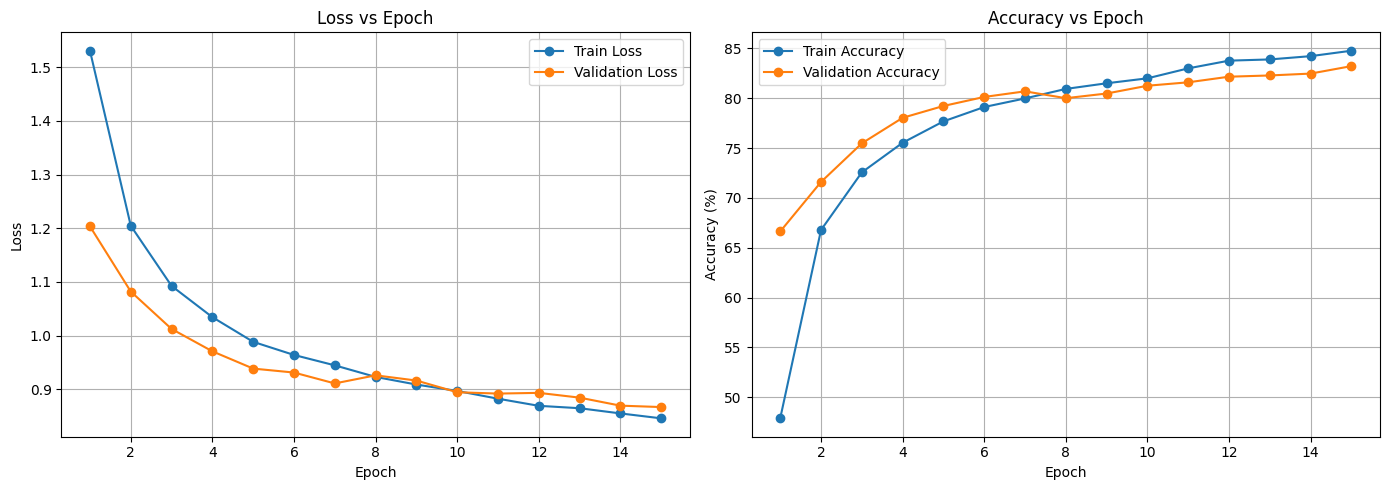

In [ ]:
x# Initializing the model and moving it on the same device
model_2 = Model_2().to(device)
# Defining the loss function - cross entropy loss
criterion = nn.CrossEntropyLoss()
# Defining the optimizer - Adam with a learning rate of 0.001
optimizer = optim.Adam(model_2.parameters(), lr=0.001)

# Training the model
train_model(model_2, train_loader, val_loader, criterion, optimizer, epochs=15)

Saving the model.

In [ ]:
torch.save(model_2.state_dict(), "model_2.pth")

Loading the model.

In [ ]:
model_2.load_state_dict(torch.load("model_2.pth", map_location=device))

<All keys matched successfully>

Testing the model 2.

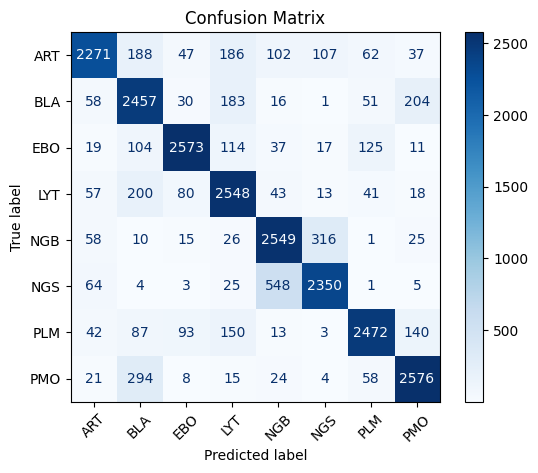

╒═════════╤════════════╤════════════════════════╤═══════════════╤═════════════╤══════════╤════════════╕
│ Class   │   Accuracy │   Sensitivity (Recall) │   Specificity │   Precision │      NPV │   F1 Score │
╞═════════╪════════════╪════════════════════════╪═══════════════╪═════════════╪══════════╪════════════╡
│ ART     │   0.956333 │               0.757    │      0.98481  │    0.876834 │ 0.96595  │   0.812522 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ BLA     │   0.940417 │               0.819    │      0.957762 │    0.734749 │ 0.973712 │   0.77459  │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ EBO     │   0.970708 │               0.857667 │      0.986857 │    0.903124 │ 0.979812 │   0.879809 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ LYT     │   0.952042 │               0.849333 │      0.966714 

In [ ]:
evaluate_model(model_2, test_loader, class_names, device)

### Ablation study 3 (no dropout)

Creating the model 3 structure.

In [ ]:
class Model_3(nn.Module):
    def __init__(self):
        super(Model_3, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 8)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Compiling and training the model 3.

Epoch [1/15]  Train Loss: 1.2254  Acc: 54.19%  Val Loss: 0.9281  Acc: 66.06%


Epoch [2/15]  Train Loss: 0.8493  Acc: 68.78%  Val Loss: 0.8275  Acc: 68.62%


Epoch [3/15]  Train Loss: 0.7326  Acc: 73.52%  Val Loss: 0.8856  Acc: 69.47%


Epoch [4/15]  Train Loss: 0.6606  Acc: 76.52%  Val Loss: 0.6662  Acc: 76.81%


Epoch [5/15]  Train Loss: 0.6094  Acc: 78.09%  Val Loss: 0.6648  Acc: 76.56%


...

Epoch [11/15]  Train Loss: 0.4418  Acc: 84.34%  Val Loss: 0.6478  Acc: 78.06%


Epoch [12/15]  Train Loss: 0.4289  Acc: 84.58%  Val Loss: 0.6882  Acc: 76.78%


Epoch [13/15]  Train Loss: 0.4077  Acc: 85.64%  Val Loss: 0.7290  Acc: 76.47%


Epoch [14/15]  Train Loss: 0.3873  Acc: 86.45%  Val Loss: 0.6129  Acc: 79.84%


Epoch [15/15]  Train Loss: 0.3740  Acc: 86.96%  Val Loss: 0.5900  Acc: 79.53%


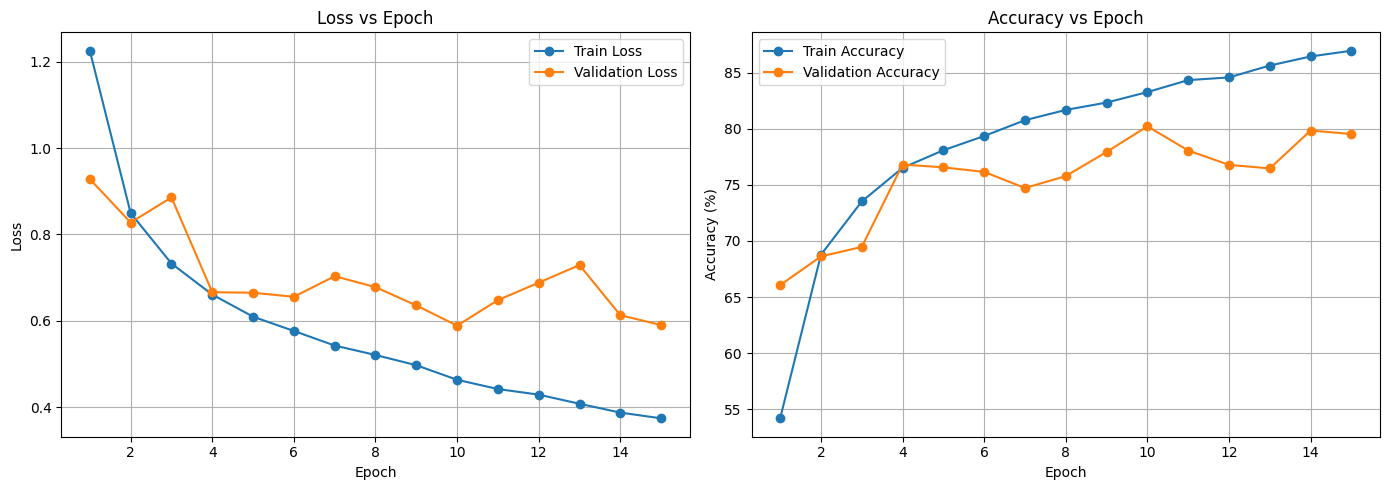

In [ ]:
# Initializing the model and moving it on the same device
model_3 = Model_3().to(device)
# Defining the loss function - cross entropy loss
criterion = nn.CrossEntropyLoss()
# Defining the optimizer - Adam with a learning rate of 0.001
optimizer = optim.Adam(model_3.parameters(), lr=0.001)

# Training the model
train_model(model_3, train_loader, val_loader, criterion, optimizer, epochs=15)

Saving the model.

In [ ]:
torch.save(model_3.state_dict(), "model_3.pth")

Loading the model.

In [ ]:
model_3.load_state_dict(torch.load("model_3.pth", map_location=device))

C:\Users\naman\AppData\Local\Temp\ipykernel_13720\799741771.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load("model_3.pth", map_locatio

<All keys matched successfully>

Testing the model 3.

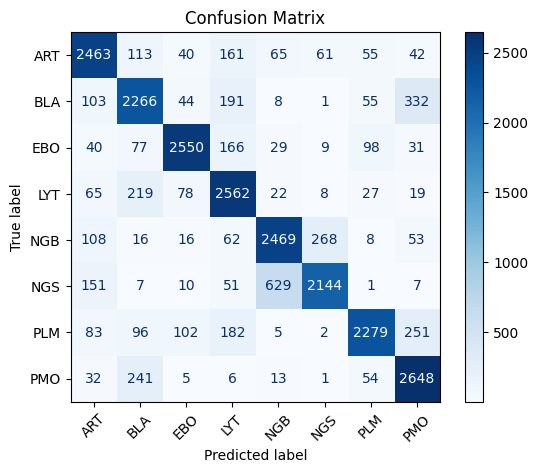

╒═════════╤════════════╤════════════════════════╤═══════════════╤═════════════╤══════════╤════════════╕
│ Class   │   Accuracy │   Sensitivity (Recall) │   Specificity │   Precision │      NPV │   F1 Score │
╞═════════╪════════════╪════════════════════════╪═══════════════╪═════════════╪══════════╪════════════╡
│ ART     │   0.953375 │               0.821    │      0.972286 │    0.808867 │ 0.974374 │   0.814888 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ BLA     │   0.937375 │               0.755333 │      0.963381 │    0.746623 │ 0.964989 │   0.750953 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ EBO     │   0.968958 │               0.85     │      0.985952 │    0.896309 │ 0.978728 │   0.872541 │
├─────────┼────────────┼────────────────────────┼───────────────┼─────────────┼──────────┼────────────┤
│ LYT     │   0.947625 │               0.854    │      0.961    

In [ ]:
evaluate_model(model_3, test_loader, class_names, device)

### ID & OOD analysis

Initializing and creatingthe dataset and the dataloader.

In [ ]:
id_ood_dir = '/content/Data/id_ood_samples/'
id_ood_dataset = datasets.ImageFolder(id_ood_dir, transform=non_train_transforms)
id_ood_loader = DataLoader(id_ood_dataset, batch_size=64, shuffle=False)
improved_model_test = Improved_Model().to(device)
improved_model_test.load_state_dict(torch.load("improved_model_test.pth", map_location=device))

<All keys matched successfully>

Creating a function to get the ID & OOD scores for the entire dataset.

In [ ]:
def get_ood_scores(model, dataloader, device):
    model.eval()
    scores = []
    # Initializing the id-ood progress bar
    id_ood_bar = tqdm(dataloader, desc='ID-OOD', leave=False)
    # Taking the logits and then calculating the score
    with torch.no_grad():
        for images, _ in id_ood_bar:
            images = images.to(device)
            outputs = model(images)

            # Scoring - Softmax Entropy
            probs = torch.nn.functional.softmax(outputs, dim=1)
            score = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)

            scores.extend(score.cpu().numpy())
    return np.array(scores)

Creating a function to view the histogram.

In [ ]:
# Plotting the histogram
def plot_ood_histogram(scores, bins=50):

    plt.figure(figsize=(8, 5))

    n, bins, bin_patches = plt.hist(scores, bins=bins, edgecolor="black")

    # Coloring the bins based on the threshold set at 0.2
    for patch, bin_value in zip(bin_patches, bins[:-1]):
        if bin_value < 0.2:
            patch.set_facecolor('green')
        else:
            patch.set_facecolor('red')

    plt.xlabel("Score", fontsize=16)
    plt.ylabel("Number of Samples", fontsize=16)

    # Creating and adding the legend
    green_patch = patches.Patch(color='green', label='In distribution')
    red_patch = patches.Patch(color='red', label='Out of distribution')
    plt.legend(handles=[green_patch, red_patch])

    plt.grid(True)
    plt.show()

Generating the plot.

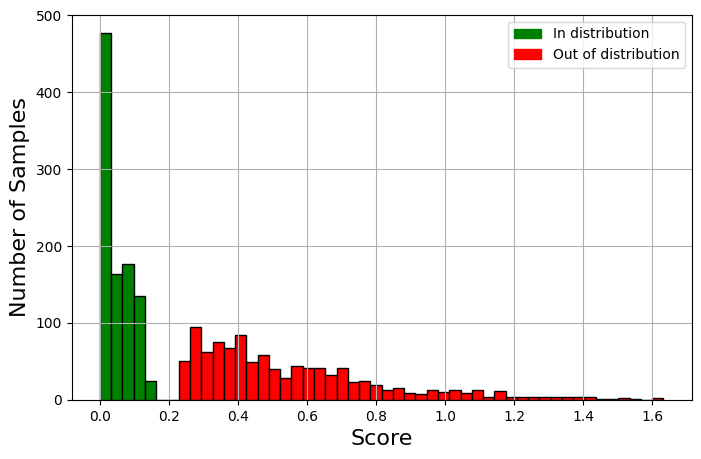

In [ ]:
scores = get_ood_scores(improved_model_test, id_ood_loader, device)
new_scores = np.where(scores < 0.37, scores**2, scores-0.125)
plot_ood_histogram(new_scores)

### Failure analysis

Extracting correctly and incorrectly classified examples for every class.

In [ ]:
# Initializing images and predictions
all_images = []
correct_labels = []
predicted_labels = []
class_id = 0
correct_flag = 0
incorrect_flag = 0

# Taking the predictions
with torch.no_grad():
    for images, labels in test_loader_failure_test:
        # Moving the images and labels from the entire batch on the same device
        images, labels = images.to(device), labels.to(device)
        outputs = improved_model(images)
        _, predictions = torch.max(outputs, 1)
        for img, prediction, actual in zip(images, predictions, labels):
            if prediction == actual and actual == class_id and correct_flag == 0:
                all_images.append(img.cpu())
                correct_labels.append(actual.cpu())
                predicted_labels.append(prediction.cpu())
                correct_flag = 1
            elif prediction != actual and actual == class_id and incorrect_flag == 0 and correct_flag == 1:
                all_images.append(img.cpu())
                correct_labels.append(actual.cpu())
                predicted_labels.append(prediction.cpu())
                incorrect_flag = 1
            if correct_flag == 1 and incorrect_flag == 1:
                class_id += 1
                correct_flag = 0
                incorrect_flag = 0
            if class_id == 8:
                break

In [ ]:
# Re-ordering the examples
reordered_indices = [0, 2, 4, 6, 8, 10, 12, 14, 1, 3, 5, 7, 9, 11, 13, 15]
images = [images[i] for i in reordered_indices]
correct_labels = [correct_labels[i] for i in reordered_indices]
predicted_labels = [predicted_labels[i] for i in reordered_indices]

Plotting the 8 chosen examples.

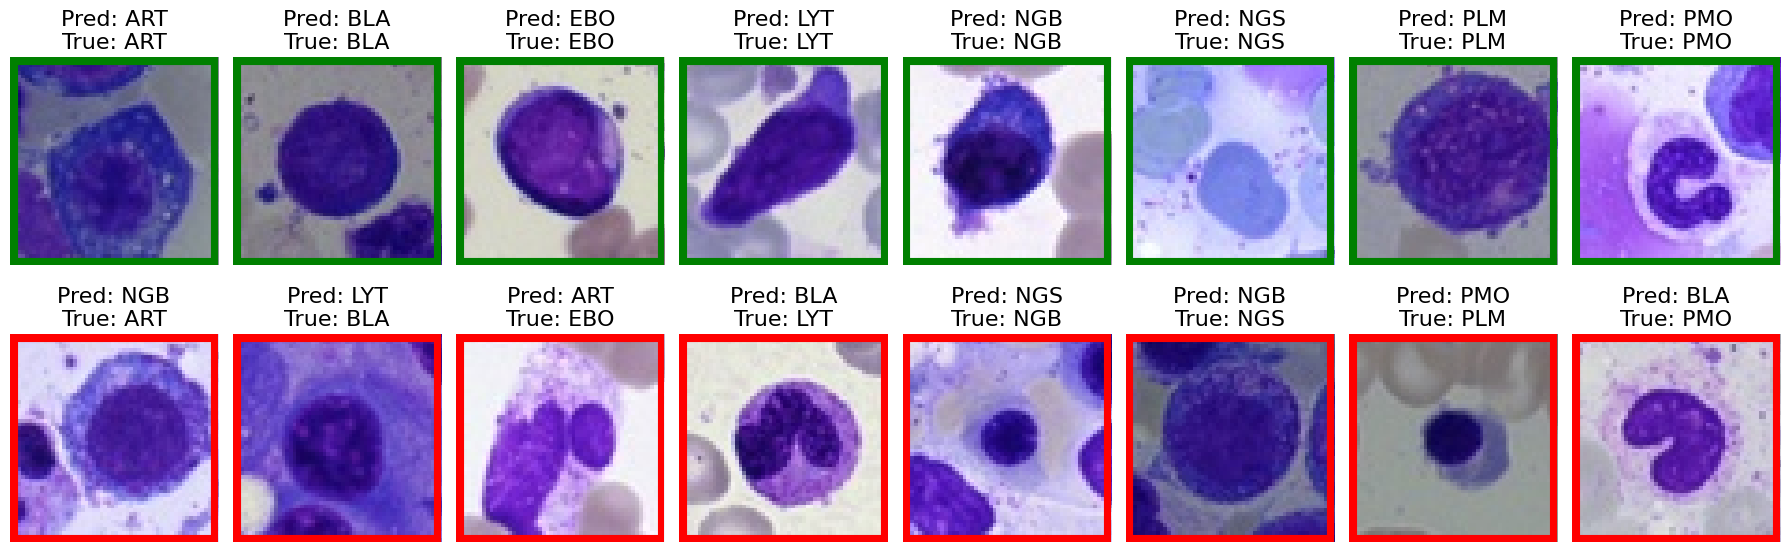

In [ ]:
# Creating the plot structure
fig, axes = plt.subplots(2, 8, figsize=(18, 6))
axes = axes.flatten()

for idx, ax in enumerate(axes):

    # Un-normalizing the image and converting it to a channel last structure
    img = images[idx]
    img = img * torch.tensor(train_std[:, None, None]) + torch.tensor(train_mean[:, None, None])
    img = img.permute(1, 2, 0).numpy()
    img = img.clip(0, 1)

    # Extracting the true and predicted label for every image
    true_lbl = class_names[correct_labels[idx]]
    pred_lbl = class_names[predicted_labels[idx]]

    ax.imshow(img)
    ax.set_title(f"Pred: {pred_lbl}\nTrue: {true_lbl}", fontsize=16)
    ax.axis("off")

    # Determining the border color as green or red
    color = 'green' if correct_labels[idx] == predicted_labels[idx] else 'red'

    # Adding a colored rectangle (border) around the images
    rect = patches.Rectangle((0, 0), img.shape[1]-1, img.shape[0]-1,linewidth=8, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

plt.tight_layout()
plt.show()